Task-1: Regression Analysis

1. Importing Librabries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

1. Load the dataset

In [2]:
df = pd.read_csv('Stock Prices Data Set.csv')
df['date'] = pd.to_datetime(df['date'])

# Handle potential missing values
df = df.dropna(subset=['open', 'high', 'low', 'close'])

# Print first few rows
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


2. Dataset Splitting

In [3]:
# Define Features (X) and Target (y)
X = df[['open', 'high', 'low']]
y = df['close']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 397968
Testing set size: 99493
Training set size: 397968
Testing set size: 99493


3. Model Fitting and Evaluation

In [4]:
# Initialize and Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.5160
R-squared Score (R2): 1.0000
Mean Squared Error (MSE): 0.5160
R-squared Score (R2): 1.0000


4. Interpret Coefficients

In [5]:
# Interpret results
print(f"Intercept: {model.intercept_:.4f}")
for feature, coef in zip(['Open', 'High', 'Low'], model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")

Intercept: -0.0084
Coefficient for Open: -0.5381
Coefficient for High: 0.7872
Coefficient for Low: 0.7510
Intercept: -0.0084
Coefficient for Open: -0.5381
Coefficient for High: 0.7872
Coefficient for Low: 0.7510


Task-2: Time-Series Analysis

1. Plotting the Time-Series Data

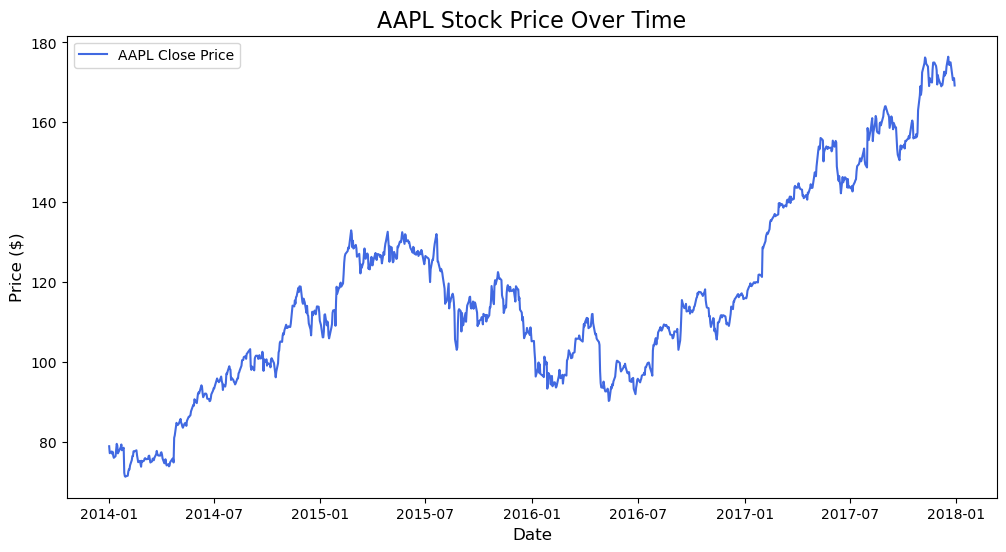

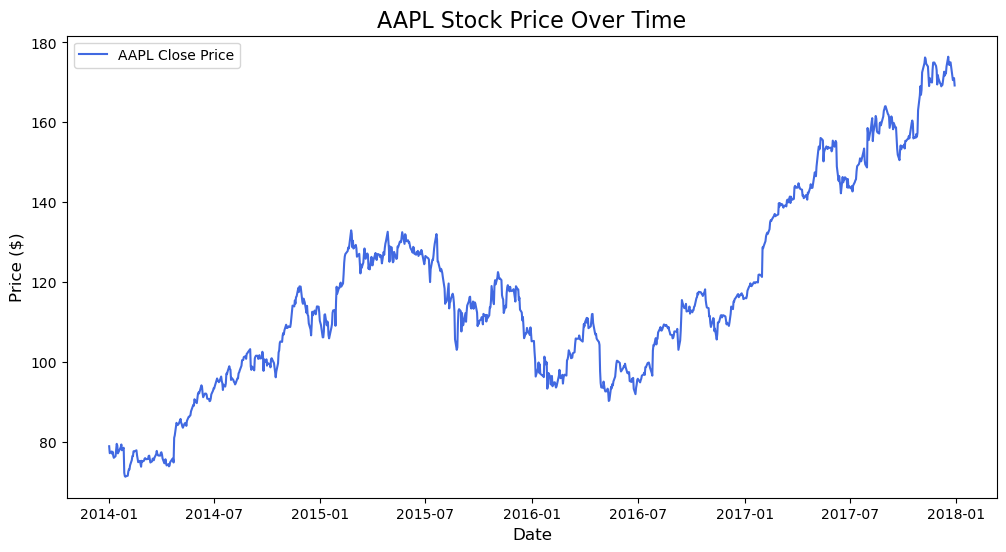

In [6]:
# Filter for a specific stock (Apple)
aapl_df = df[df['symbol'] == 'AAPL'].sort_values('date')
aapl_df.set_index('date', inplace=True)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(aapl_df['close'], color='royalblue', label='AAPL Close Price')
plt.title('AAPL Stock Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.show()

2. Time-Series Decomposition

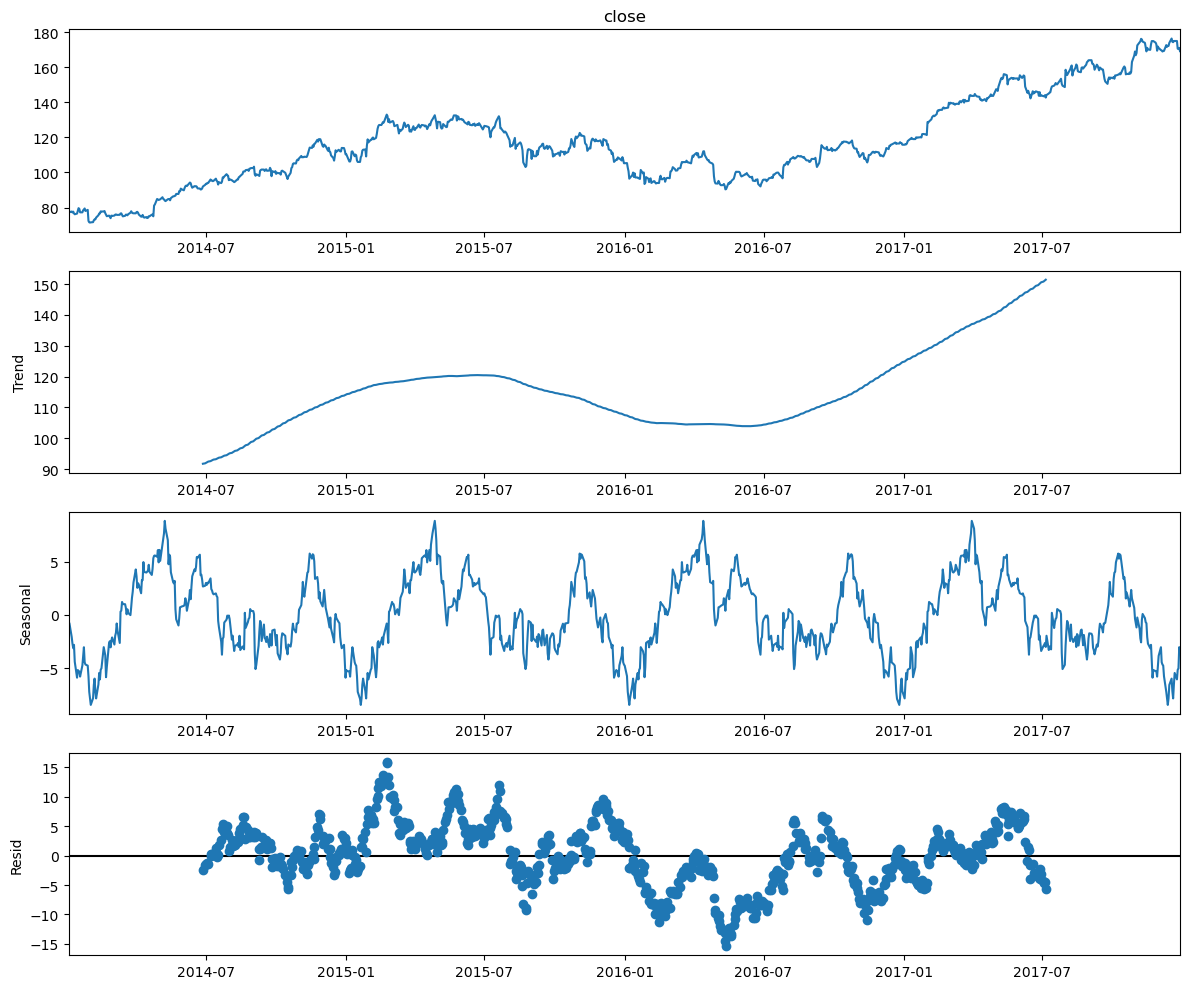

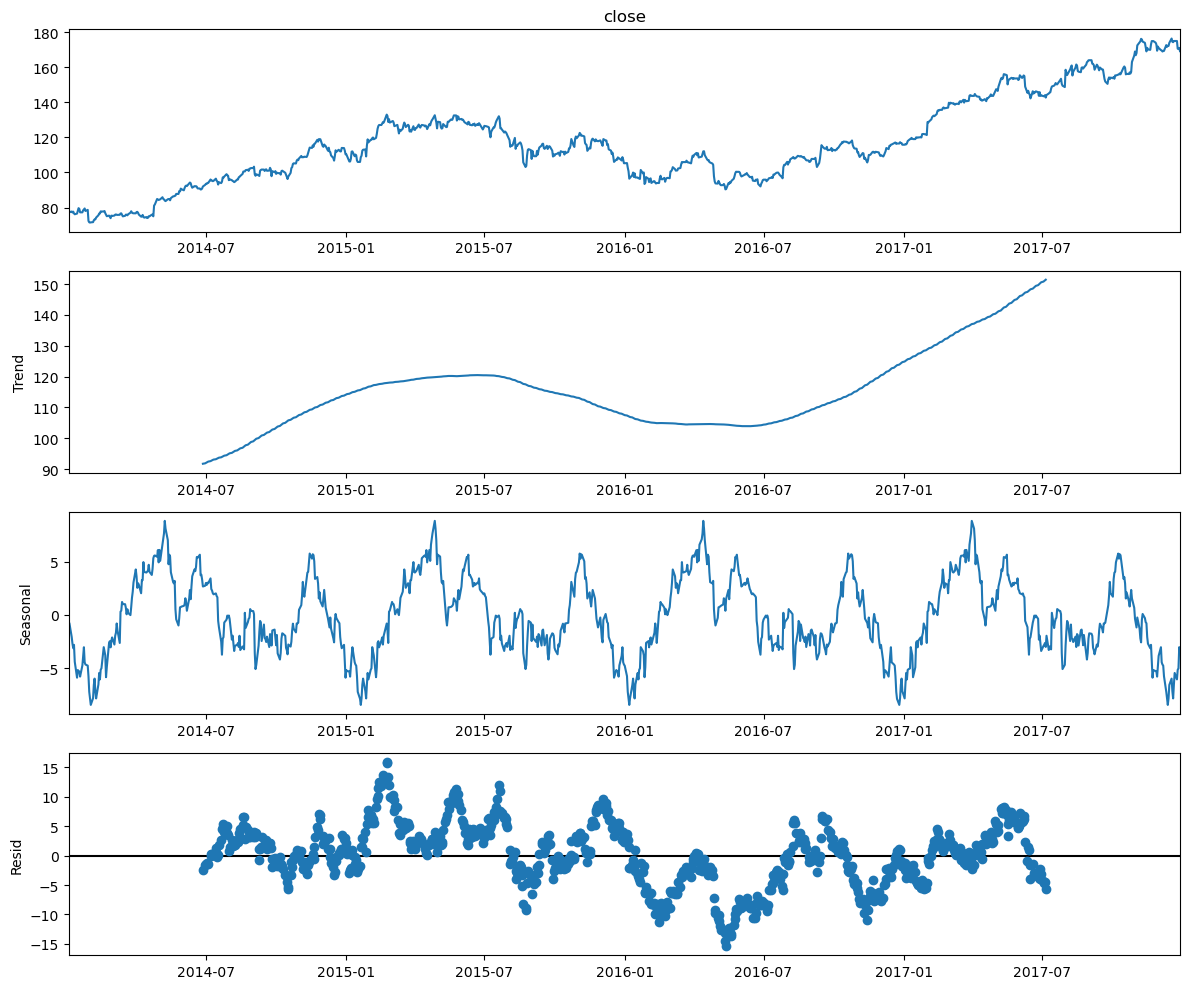

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to handle business days and fill gaps for a continuous period
aapl_ts = aapl_df['close'].resample('B').ffill().dropna()

# Decompose using an annual period (approx 252 trading days)
result = seasonal_decompose(aapl_ts, model='additive', period=252)

# Plot components
fig = result.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

3. Moving Average Smoothing

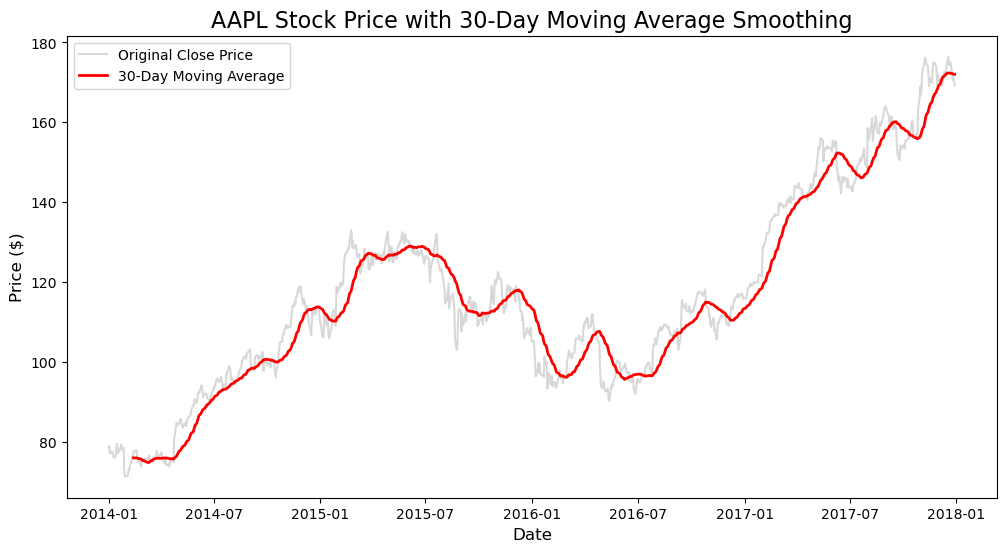

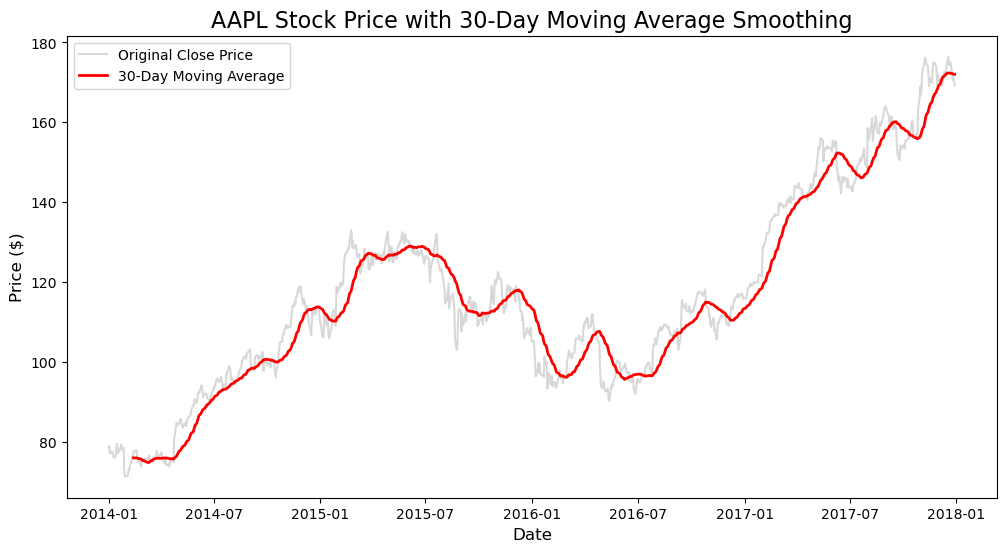

In [8]:
# Calculate 30-day Moving Average (MA)
aapl_df['MA30'] = aapl_df['close'].rolling(window=30).mean()

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(aapl_df['close'], alpha=0.3, label='Original Close Price', color='grey')
plt.plot(aapl_df['MA30'], color='red', label='30-Day Moving Average', linewidth=2)
plt.title('AAPL Stock Price with 30-Day Moving Average Smoothing', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.show()